In [3]:
import pandas as pd

datos = pd.read_csv("dataset_entrenamiento_mundial_2026.csv")
datos.head()

,equipo,partido_jugado,victoria_clasica,puntos_victoria_w,partidos_jugados_w,Ratio_Clasico,Score_Poder,Indice_Presion,PTS,Puntos,Promedio_Rivales,Forma_Actual
0,France,162,108,160.3,243.4,0.666667,160.3,0.658587,6,1894.40,1554.693333,4.66
1,Argentina,158,105,153.5,243.0,0.664557,153.5,0.631687,6,1901.93,1510.506667,4.53
2,Belgium,151,100,153.4,231.3,0.662252,153.4,0.663208,2,1727.88,1490.630000,1.49
3,Portugal,157,99,142.6,236.4,0.630573,142.6,0.603215,4,1766.74,1544.210000,3.09
4,Spain,151,96,142.3,230.5,0.635762,142.3,0.617354,4,1864.32,1492.813333,2.99


In [4]:
datos_filt = datos[['equipo','Ratio_Clasico','Score_Poder','Indice_Presion','Forma_Actual']].copy()
datos_filt.head()

,equipo,Ratio_Clasico,Score_Poder,Indice_Presion,Forma_Actual
0,France,0.666667,160.3,0.658587,4.66
1,Argentina,0.664557,153.5,0.631687,4.53
2,Belgium,0.662252,153.4,0.663208,1.49
3,Portugal,0.630573,142.6,0.603215,3.09
4,Spain,0.635762,142.3,0.617354,2.99


In [5]:
from sklearn.preprocessing import MinMaxScaler

print("Calculando proyecciones de Fase para el Mundial 2026...")

# 1. Escalar los datos (Para que 'Score_Poder' que vale 160 no aplaste a 'Ratio_Clasico' que vale 0.6)
scaler = MinMaxScaler()
columnas_modelo = ['Ratio_Clasico', 'Score_Poder', 'Indice_Presion', 'Forma_Actual']

# Creamos copias escaladas de las columnas (valores del 0 al 1)
df_escalado = pd.DataFrame(scaler.fit_transform(datos_filt[columnas_modelo]), columns=columnas_modelo)

# 2. Algoritmo de Ranking de Poder (Power Score)
# Le daremos un peso a cada variable según su importancia predictiva.
# Puedes ajustar estos porcentajes como consideres mejor.
datos_filt['Poder_Total'] = (
    (df_escalado['Forma_Actual'] * 0.45) +  
    (df_escalado['Score_Poder'] * 0.20) +   
    (df_escalado['Ratio_Clasico'] * 0.30) + 
    (df_escalado['Indice_Presion'] * 0.05)  
)

# 3. Ordenamos a los equipos del mejor al peor basado en nuestro nuevo puntaje
datos_filt = datos_filt.sort_values(by='Poder_Total', ascending=False).reset_index(drop=True)

# 4. Asignamos la fase matemática según el nuevo formato de 48 equipos (Mundial 2026)
def asignar_fase_mundial(ranking):
    if ranking == 1:
        return '🏆 Campeón'
    elif ranking == 2:
        return '🥈 Subcampeón'
    elif ranking <= 4:
        return '🎖️ Semifinales'
    elif ranking <= 8:
        return '🎫 Cuartos de Final'
    elif ranking <= 16:
        return '🎟️ Octavos de Final'
    elif ranking <= 32:
        return '✈️ Dieciseisavos de Final'
    else:
        return '❌ Fase de Grupos'

# Aplicamos la función usando el índice (+1 porque el índice empieza en 0)
datos_filt['Proyeccion_Torneo'] = (datos_filt.index + 1).map(asignar_fase_mundial)

# 5. Formateamos el Poder_Total para que sea más legible (de 0 a 100)
datos_filt['Poder_Total'] = round(datos_filt['Poder_Total'] * 100, 2)

print("✅ Proyecciones calculadas con éxito.\n")
display(datos_filt[['equipo', 'Poder_Total', 'Proyeccion_Torneo']])

Calculando proyecciones de Fase para el Mundial 2026...
✅ Proyecciones calculadas con éxito.



,equipo,Poder_Total,Proyeccion_Torneo
0,France,97.31,🏆 Campeón
1,Argentina,94.60,🥈 Subcampeón
2,Germany,83.55,🎖️ Semifinales
3,Mexico,81.66,🎖️ Semifinales
4,Brazil,80.45,🎫 Cuartos de Final
5,United States,78.81,🎫 Cuartos de Final
6,Portugal,76.96,🎫 Cuartos de Final
7,England,76.79,🎫 Cuartos de Final
8,Spain,76.57,🎟️ Octavos de Final
9,Morocco,75.95,🎟️ Octavos de Final


## *Modelo de Poisson*

## Cálculo de fuerzas (ATK y DEF)

In [8]:
df = pd.read_csv("datos_modelo_poisson.csv")
df['equipo'] = df['equipo'].replace({'Curaçao':'Curacao'})
df_historico = df[df['equipo'].isin(datos_filt['equipo'].unique())].copy()
df_historico.head()

,equipo,partidos_jugados,victoria,empate,derrota,goles_favor,goles_contra,Ratio V/PJ
0,Mexico,208,114,48,46,329.0,199.0,0.548077
1,France,162,108,31,23,344.0,139.0,0.666667
2,Argentina,158,105,33,20,315.0,102.0,0.664557
3,Japan,163,102,28,33,372.0,141.0,0.625767
4,United States,188,100,36,52,353.0,194.0,0.531915


In [9]:
import numpy as np

# 1. Promedio de goles por partido para cada equipo
df_historico['Goles_Anotados_PP'] = df_historico['goles_favor'] / df_historico['partidos_jugados']
df_historico['Goles_Recibidos_PP'] = df_historico['goles_contra'] / df_historico['partidos_jugados']

# 2. Promedio global
# Calculamos la media de todos los equipos para saber cuántos goles son "normales"
promedio_global_goles = df_historico['Goles_Anotados_PP'].mean()

# 3. Fuerza de Ataque y Defensa
df_historico['Fuerza_Ataque_Hist'] = df_historico['Goles_Anotados_PP'] / promedio_global_goles
df_historico['Fuerza_Defensa_Hist'] = df_historico['Goles_Recibidos_PP'] / promedio_global_goles

print("✅ Fuerzas calculadas. Vista previa de los titanes:")
display(df_historico[['equipo', 'Fuerza_Ataque_Hist', 'Fuerza_Defensa_Hist']].head())
df_hist = df_historico[['equipo', 'Fuerza_Ataque_Hist', 'Fuerza_Defensa_Hist']].copy()

✅ Fuerzas calculadas. Vista previa de los titanes:


,equipo,Fuerza_Ataque_Hist,Fuerza_Defensa_Hist
0,Mexico,0.929660,0.562317
1,France,1.248058,0.504303
2,Argentina,1.171777,0.379433
3,Japan,1.341365,0.508420
4,United States,1.103592,0.606506


In [10]:
df_dinam = pd.read_csv("Datos/Dinámicos/goles_dinamicos.csv")
df_dinam.head()

,Equipo,GF,GC,J
0,Mexico,6,0,3
1,South Africa,2,3,3
2,South Korea,2,3,3
3,Czech Republic,2,6,3
4,Switzerland,7,3,3


In [11]:
alpha=0.5
df_dinam['Goles_Anotados_PP'] = (df_dinam['GF']+alpha) / (df_dinam['J']+alpha) #Suavizado para evitar que la fuerza de defensa sea 0
df_dinam['Goles_Recibidos_PP'] = (df_dinam['GC']+alpha) / (df_dinam['J']+alpha)

# 2. Promedio global
promedio_global_goles = df_dinam['Goles_Anotados_PP'].mean()

# 3. Fuerza de Ataque y Defensa
df_dinam['Fuerza_Ataque_dinam'] = df_dinam['Goles_Anotados_PP'] / promedio_global_goles
df_dinam['Fuerza_Defensa_dinam'] = df_dinam['Goles_Recibidos_PP'] / promedio_global_goles

print("✅ Fuerzas calculadas. Vista previa de los titanes:")
df_dinam = df_dinam.rename(columns={'Equipo':'equipo'})
display(df_dinam[['equipo', 'Fuerza_Ataque_dinam', 'Fuerza_Defensa_dinam']].head())
df_din = df_dinam[['equipo', 'Fuerza_Ataque_dinam', 'Fuerza_Defensa_dinam']].copy()

✅ Fuerzas calculadas. Vista previa de los titanes:


,equipo,Fuerza_Ataque_dinam,Fuerza_Defensa_dinam
0,Mexico,1.318681,0.101437
1,South Africa,0.507185,0.710059
2,South Korea,0.507185,0.710059
3,Czech Republic,0.507185,1.318681
4,Switzerland,1.521555,0.710059


In [12]:
fusion = pd.merge(df_hist, df_din, on='equipo', how='inner')
fusion.head()

,equipo,Fuerza_Ataque_Hist,Fuerza_Defensa_Hist,Fuerza_Ataque_dinam,Fuerza_Defensa_dinam
0,Mexico,0.929660,0.562317,1.318681,0.101437
1,France,1.248058,0.504303,1.846154,0.426036
2,Argentina,1.171777,0.379433,1.562130,0.142012
3,Japan,1.341365,0.508420,1.846154,0.710059
4,United States,1.103592,0.606506,1.846154,0.426036


In [13]:
fusion['Fuerza_At_Final'] = fusion['Fuerza_Ataque_Hist']*0.4 + fusion['Fuerza_Ataque_dinam']*0.6
fusion['Fuerza_De_Final'] = fusion['Fuerza_Defensa_Hist']*0.4 + fusion['Fuerza_Defensa_dinam']*0.6
fusion.head()

,equipo,Fuerza_Ataque_Hist,Fuerza_Defensa_Hist,Fuerza_Ataque_dinam,Fuerza_Defensa_dinam,Fuerza_At_Final,Fuerza_De_Final
0,Mexico,0.929660,0.562317,1.318681,0.101437,1.163073,0.285789
1,France,1.248058,0.504303,1.846154,0.426036,1.606916,0.457342
2,Argentina,1.171777,0.379433,1.562130,0.142012,1.405989,0.236980
3,Japan,1.341365,0.508420,1.846154,0.710059,1.644238,0.629404
4,United States,1.103592,0.606506,1.846154,0.426036,1.549129,0.498224


## Función de simulación_poisson

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import poisson

prom_hist = df_historico['Goles_Anotados_PP'].mean()

def heatmap_partido_poisson(equipo_A, equipo_B, df_fuerzas, promedio_global_hist = prom_hist, max_goles=5):
    try:
        # Extraer estadísticas híbridas del Equipo A
        ataque_A = df_fuerzas.loc[df_fuerzas['equipo'] == equipo_A, 'Fuerza_At_Final'].values[0]
        defensa_A = df_fuerzas.loc[df_fuerzas['equipo'] == equipo_A, 'Fuerza_De_Final'].values[0]
        
        # Extraer estadísticas híbridas del Equipo B
        ataque_B = df_fuerzas.loc[df_fuerzas['equipo'] == equipo_B, 'Fuerza_At_Final'].values[0]
        defensa_B = df_fuerzas.loc[df_fuerzas['equipo'] == equipo_B, 'Fuerza_De_Final'].values[0]
    except IndexError:
        return "Error: Verifica que los nombres de los equipos existan en el dataframe proporcionado."

    # Calcular Goles Esperados (Lambda)
    lambda_A = ataque_A * defensa_B * promedio_global_hist
    lambda_B = ataque_B * defensa_A * promedio_global_hist

    # Calcular probabilidades individuales para cada cantidad de goles (0 a max_goles)
    prob_A = [poisson.pmf(i, lambda_A) for i in range(max_goles + 1)]
    prob_B = [poisson.pmf(i, lambda_B) for i in range(max_goles + 1)]

    prob_victoria_A = 0
    prob_empate = 0
    prob_victoria_B = 0

    for i in range(max_goles + 1):
        for j in range(max_goles + 1):
            prob = prob_A[i] * prob_B[j]
            if i > j:
                prob_victoria_A += prob
            elif i == j:
                prob_empate += prob
            else:
                prob_victoria_B += prob

    print(f"PREDICCIÓN POISSON: {equipo_A} vs {equipo_B}")
    print("-" * 40)
    print(f"⚽ Goles Esperados (Lambda): {equipo_A} [{lambda_A:.2f}] - {equipo_B} [{lambda_B:.2f}]")
    print(f"🏆 Victoria {equipo_A}: {prob_victoria_A * 100:.1f}%")
    print(f"🤝 Empate: {prob_empate * 100:.1f}%")
    print(f"🏆 Victoria {equipo_B}: {prob_victoria_B * 100:.1f}%\n")
    

    # Multiplicación cruzada para crear la matriz de probabilidades exactas
    # np.outer crea una cuadrícula perfecta multiplicando cada fila por cada columna
    matriz_prob = np.outer(prob_A, prob_B)

    # --- Creación del Heatmap ---
    plt.figure(figsize=(8, 6))
    
    # Multiplicamos por 100 para mostrar porcentajes más legibles
    sns.heatmap(matriz_prob * 100, annot=True, fmt=".1f", cmap="YlOrRd", 
                xticklabels=range(max_goles + 1), yticklabels=range(max_goles + 1),
                cbar_kws={'label': 'Probabilidad (%)'})
    
    plt.title(f"Probabilidad de Marcador Exacto (%)\n{equipo_A} vs {equipo_B}", fontsize=14, pad=15)
    plt.xlabel(f"Goles de {equipo_B}", fontsize=12)
    plt.ylabel(f"Goles de {equipo_A}", fontsize=12)
    
    # Invertimos el eje Y para que el (0,0) quede en la esquina superior izquierda (estándar de matrices)
    plt.gca().invert_yaxis() 
    
    plt.tight_layout()
    plt.show()

    return prob_victoria_A, prob_empate, prob_victoria_B

## Simulaciones

PREDICCIÓN POISSON: Spain vs Uruguay
----------------------------------------
⚽ Goles Esperados (Lambda): Spain [1.81] - Uruguay [0.43]
🏆 Victoria Spain: 70.3%
🤝 Empate: 20.7%
🏆 Victoria Uruguay: 8.0%



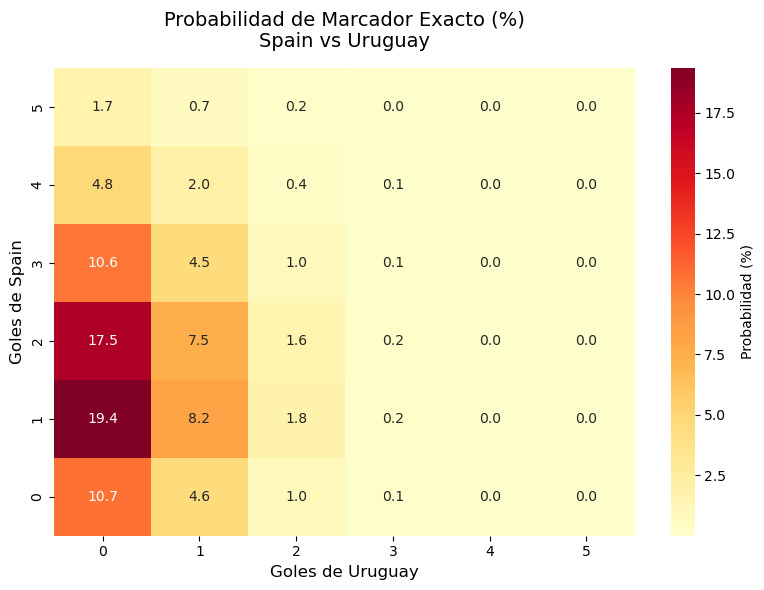

Simulación terminada


In [17]:
heatmap_partido_poisson('Spain', 'Uruguay', fusion)
print('Simulación terminada')

PREDICCIÓN POISSON: Cape Verde vs Saudi Arabia
----------------------------------------
⚽ Goles Esperados (Lambda): Cape Verde [1.45] - Saudi Arabia [0.65]
🏆 Victoria Cape Verde: 56.1%
🤝 Empate: 26.9%
🏆 Victoria Saudi Arabia: 16.7%



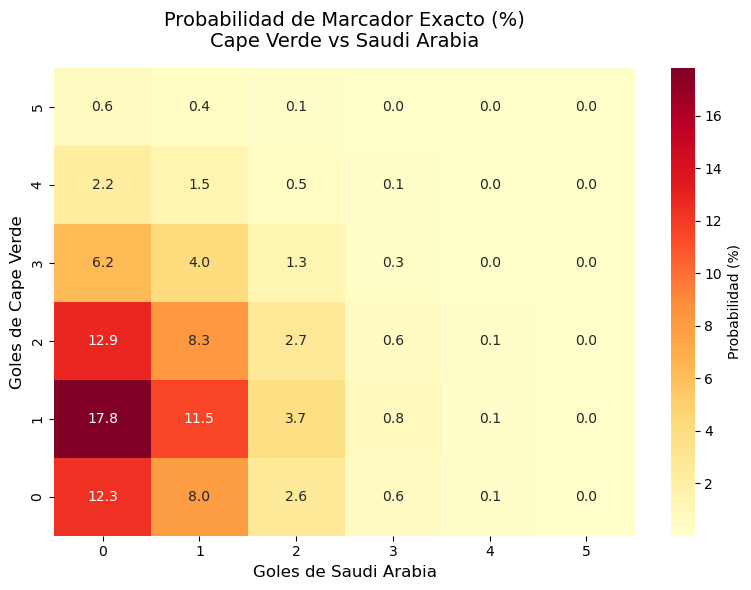

Simulación terminada


In [18]:
heatmap_partido_poisson('Cape Verde', 'Saudi Arabia', fusion)
print('Simulación terminada')